In [311]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [312]:
df = pd.read_csv("income_evaluation.csv")
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [313]:
# EDA

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              32561 non-null  int64
 1    workclass       32561 non-null  str  
 2    fnlwgt          32561 non-null  int64
 3    education       32561 non-null  str  
 4    education-num   32561 non-null  int64
 5    marital-status  32561 non-null  str  
 6    occupation      32561 non-null  str  
 7    relationship    32561 non-null  str  
 8    race            32561 non-null  str  
 9    sex             32561 non-null  str  
 10   capital-gain    32561 non-null  int64
 11   capital-loss    32561 non-null  int64
 12   hours-per-week  32561 non-null  int64
 13   native-country  32561 non-null  str  
 14   income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.5 MB


In [314]:
df.describe()


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [315]:
# Replace ? with NaN
df.replace("?", np.nan, inplace=True)
df.replace(" ?", np.nan, inplace=True)

#remove leading and trailing spaces from column names
df.columns = df.columns.str.strip()

#filling missing categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Then filling missing values with the mode for categorical columns
for column in categorical_cols:
       df[column] = df[column].fillna(df[column].mode()[0])

C:\Users\PRIYA SRIVASTAVA\AppData\Local\Temp\ipykernel_10360\3663106930.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [316]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

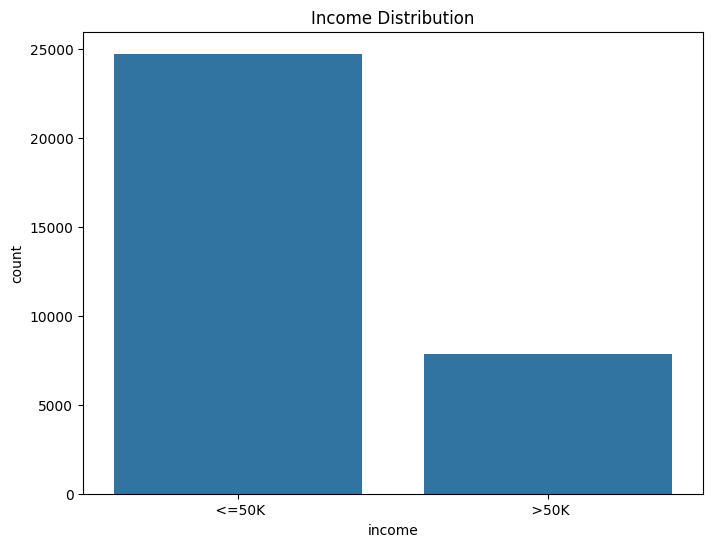

In [317]:
# Visualization

# Income distribution
plt.figure(figsize=(8, 6))
sns.countplot(x="income", data=df)
plt.title("Income Distribution")
plt.show()

Interpretation:

The income distribution plot shows that the dataset is imbalanced with significantly  more individuals earning <= 50K compared to >= 50K. This class imbalance may bias  machine learning model towards the majority class making  evaluation metrics  such as precision, recall and F1-score more important than accuracy alone.

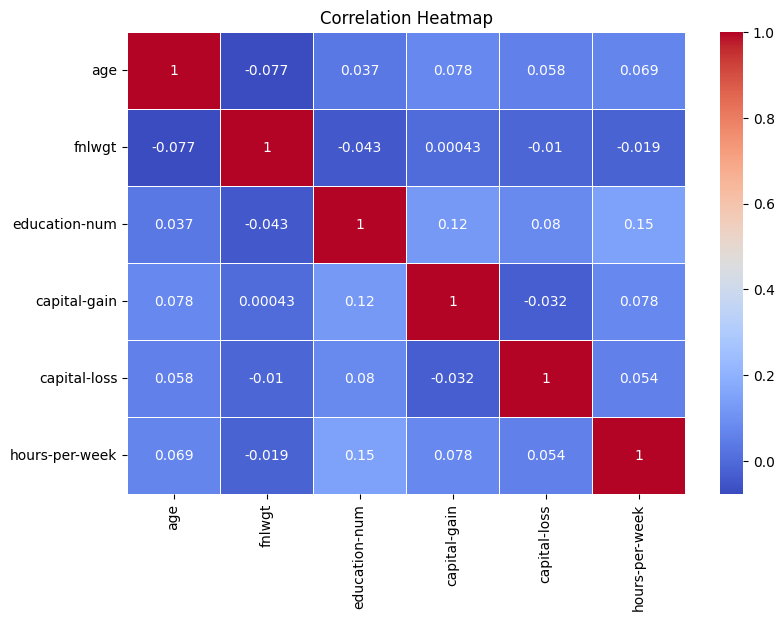

In [318]:
# Correlation heatmap

num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(9,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

Interpretation:

The correlation heatmap indicates that the most numerical features have weak linear realtionship with each other. No significant multicollinearity is observed, which suggests that the features contribute realtively independent  information to the model.

In [319]:
# Checking skewness

print("\nSkewness:\n")
print(df[num_cols].skew())


Skewness:

age                0.558743
fnlwgt             1.446980
education-num     -0.311676
capital-gain      11.953848
capital-loss       4.594629
hours-per-week     0.227643
dtype: float64


In [320]:
# Highly skewed columns

skewed_cols = df[num_cols].skew().abs()
skewed_cols = skewed_cols[skewed_cols >1]
print(skewed_cols)

fnlwgt           1.446980
capital-gain    11.953848
capital-loss     4.594629
dtype: float64


In [321]:
# Log transformation for skewed columns

for col in skewed_cols.index:
    df[col] = np.log1p(df[col])

In [322]:
# Comparing skewnessbefore and after log transformation

print("\nskewness before log transformation:\n")
print(skewed_cols)
print("\nskewness after log transformation:\n")
print(df[skewed_cols.index].skew())




skewness before log transformation:

fnlwgt           1.446980
capital-gain    11.953848
capital-loss     4.594629
dtype: float64

skewness after log transformation:

fnlwgt         -0.842461
capital-gain    3.096144
capital-loss    4.307537
dtype: float64


Although log transformation reduced skewness significantly , some variables like capital gain and capital loss remained  highly skewed  due to large number of zero value and a few extreme outliers.

Special Observation  for capital-gain and capital-loss, features were highly zero inflated , meaning most observations contained zero values while only few contained extremely large values.
Beacuse of this distribution IQR = Q3 - Q1 = 0
I initially applied IQR on skewed features, but capital-gain and capital-loss  beacame entirely zero. then I found that these features were zero inflated, causing Q1 and Q3 both to zero. This made the IQR zero,so every positive value was treated as an outlier. To solve this I excluded  thses feature  from IQR treatment.

In [323]:
exclude_cols = ["capital-gain","capital-loss"]

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    if col in exclude_cols:
        continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

In [324]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.555603,11.997688,10.124321,0.734621,0.350305,41.202451
std,13.556130,0.593053,2.459770,2.454738,1.584581,6.187005
min,17.000000,10.628401,4.500000,0.000000,0.000000,32.500000
25%,28.000000,11.676981,9.000000,0.000000,0.000000,40.000000
50%,37.000000,12.091542,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.376035,12.000000,0.000000,0.000000,45.000000
max,78.000000,13.424615,16.000000,11.512925,8.379539,52.500000


In [325]:
# Removing unnecessary columns
df.drop(["age", "relationship"], axis=1, inplace=True)

In [326]:
# Encode categorical variables

categorical_cols = df.select_dtypes(include='object').columns

# Label Encoding for target variable

label_encoder = LabelEncoder()
df["income"] = label_encoder.fit_transform(df["income"])

C:\Users\PRIYA SRIVASTAVA\AppData\Local\Temp\ipykernel_10360\1138724751.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [327]:


# One Hot Encoding for other categorical variables

categorical_cols = categorical_cols.drop("income")

df = pd.get_dummies(df, columns = categorical_cols, drop_first= True)

In [328]:
# Split faetures and target variable

X = df.drop("income", axis=1)
y = df["income"]

In [329]:
# save column names for later use

model_columns = list(X.columns)
joblib.dump(model_columns, "model_columns.pkl")

['model_columns.pkl']

In [330]:
# Train Test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [331]:
# Feature Scaling

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)


In [332]:
# save scaler

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [333]:
# Model Training

models= {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier()
}

In [334]:
results = []

for name, model in models.items():

    model.fit(x_train_scaled, y_train)

    # Predict on test set
    y_train_pred = model.predict(x_train_scaled)
    y_test_pred = model.predict(x_test_scaled)

    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Overfitting check
    difference = train_acc - test_acc

    if difference > 0.1:  # Adjust threshold as needed
        status = "Overfitting"
    else:
        status = "Good Fit"

    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Difference": difference,
        "Overfitting Status": status
        })
    

Overfitting_results = pd.DataFrame(results)
Overfitting_results





,Model,Train Accuracy,Test Accuracy,Difference,Overfitting Status
0,Logistic Regression,0.843059,0.845233,-0.002174,Good Fit
1,Random Forest,0.997697,0.833103,0.164594,Overfitting
2,XGBoost,0.889972,0.869492,0.020481,Good Fit
3,SVM,0.851159,0.841855,0.009305,Good Fit
4,Decision Tree,0.997773,0.811608,0.186166,Overfitting


In [335]:
# Creating model using XGBoost

xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(x_train_scaled, y_train)



,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [336]:
#important_df = pd.DataFrame({
 #  "Feature": X.columns,
  # "Importance": xgb_model.feature_importances_
#}).sort_values(by="Importance", ascending=False)

#print(important_df.head(14))

Interpretation:

I used XGBoost feature importance scores to identify the most influential predictors contributing to income classificatio features like marital status, education level, capital gain, and occupation showed the highest importance in predicting income levels. So I deleted the age and relationship column as these two are less important features.

             

In [337]:
# Predictions

y_train_pred = xgb_model.predict(x_train_scaled)
y_test_pred = xgb_model.predict(x_test_scaled)

In [338]:
#Evaluation
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.8899723587223587
Test Accuracy: 0.8694917856594503


In [339]:
# Classification report and confusion matrix


print("Classification Report:\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.92      4942
           1       0.78      0.64      0.70      1571

    accuracy                           0.87      6513
   macro avg       0.83      0.79      0.81      6513
weighted avg       0.86      0.87      0.87      6513

Confusion Matrix:
 [[4652  290]
 [ 560 1011]]


In [340]:
# save the model

joblib.dump(xgb_model, "xgb_model.pkl")


['xgb_model.pkl']

In [341]:
# save label encoder

joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']